# DTS data - loss modulus Predictor

**Author:** Lab of Farm Structures
**Date:** 2026-05

## Import libraries

In [2]:
import pandas as pd
import kennard_stone as ks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import shap
from prince import FAMD
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
import seaborn as sns
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar
from scipy.stats import pearsonr

## Load data

In [3]:
model_loss = 'rheological_DTS_data_loss_LM'

df_loss = pd.read_csv(f'{model_loss}.csv')
df_loss.head()

,temperature,study_id,instance,mw_phbv,additive1_type,additive1_percentage_wt,additive2_type,additive2_percentage_wt,hb_ratio_mol,hv_ratio_mol,loss_modulus,log_loss_modulus,log_mw
0,-12.5,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,436.893780,2.640376,5.690196
1,0.0,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,406.854191,2.609439,5.690196
2,12.5,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,365.762765,2.563199,5.690196
3,25.0,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,306.683929,2.486691,5.690196
4,37.5,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,217.678942,2.337816,5.690196


In [3]:
df_loss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature              465 non-null    float64
 1   study_id                 465 non-null    int64  
 2   instance                 465 non-null    object 
 3   mw_phbv                  465 non-null    float64
 4   additive1_type           465 non-null    object 
 5   additive1_percentage_wt  465 non-null    float64
 6   additive2_type           465 non-null    object 
 7   additive2_percentage_wt  465 non-null    float64
 8   hb_ratio_mol             465 non-null    float64
 9   hv_ratio_mol             465 non-null    float64
 10  loss_modulus             465 non-null    float64
 11  log_loss_modulus         465 non-null    float64
 12  log_mw                   465 non-null    float64
dtypes: float64(9), int64(1), object(3)
memory usage: 47.4+ KB


## Exclude randomly one instance from multi-instance studies

In [4]:
np.random.seed(123)

# Count rows per Study_id and Instance
instance_row_counts = (
    df_loss.groupby(['study_id', 'instance'])
    .size()  # counts rows per Study_id-Instance
)

# Keep only instances with at least 5 rows
valid_instances = instance_row_counts[instance_row_counts >= 5]

# Study_ids with more than one instance
instance_counts = valid_instances.groupby('study_id').size()

# Keep only Study_ids with more than one valid instance
multi_study_ids = instance_counts[instance_counts > 4].index

# Randomly select ONE instance per such Study_id
excluded_instances = (
    df_loss[df_loss['study_id'].isin(multi_study_ids)]
    .groupby('study_id')['instance']
    .apply(lambda x: np.random.choice(x.unique()))
    .reset_index(name='Excluded_Instance')
)

#reduce the amount of val set
# excluded_instances = excluded_instances[
# ~excluded_instances['study_id'].isin([46, 12])   # 58
#]

# Merge back to create a row-aligned mask
df_with_exclusion = df_loss.merge(
    excluded_instances,
    on='study_id',
    how='left'
)

# Rows to exclude: those matching the randomly selected instance
exclude_mask = df_with_exclusion['instance'] == df_with_exclusion['Excluded_Instance']

# Split the dataframes
df_val = df_with_exclusion[exclude_mask].drop(columns='Excluded_Instance')
df_loss = df_with_exclusion[~exclude_mask].drop(columns='Excluded_Instance')

print(df_val[['study_id', 'instance']].drop_duplicates())

     study_id instance
165        12       3b
214        21       5a
401        59        3


In [5]:
print('train/test set size:', df_loss.shape, '\n Val set size',df_val.shape)

train/test set size: (435, 13) 
 Val set size (30, 13)


## Select Features and Target

In [6]:
df_loss.columns

Index(['temperature', 'study_id', 'instance', 'mw_phbv', 'additive1_type',
       'additive1_percentage_wt', 'additive2_type', 'additive2_percentage_wt',
       'hb_ratio_mol', 'hv_ratio_mol', 'loss_modulus', 'log_loss_modulus',
       'log_mw'],
      dtype='object')

In [7]:
features = [
    'temperature',
    'hb_ratio_mol',
    'hv_ratio_mol',
    'log_mw',
    'additive1_type',
    'additive1_percentage_wt',
    'additive2_type',
    'additive2_percentage_wt'
]

# target = 'log_loss_modulus'
target = 'log_loss_modulus'

measure_unit = 'log_MPa'

In [8]:
# Create DataFrame
df_new = df_loss[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.tail()

,temperature,hb_ratio_mol,hv_ratio_mol,log_mw,additive1_type,additive1_percentage_wt,additive2_type,additive2_percentage_wt,log_loss_modulus
460,70.0,100.0,0.0,5.740363,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,1.765227
461,80.0,100.0,0.0,5.740363,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,1.646115
462,90.0,100.0,0.0,5.740363,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,1.609078
463,100.0,100.0,0.0,5.740363,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,1.601922
464,110.0,100.0,0.0,5.740363,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,1.586689


In [9]:
df_final.shape

(435, 9)

In [10]:
# numerical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# categorical columns 
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

## Plot feature distribution

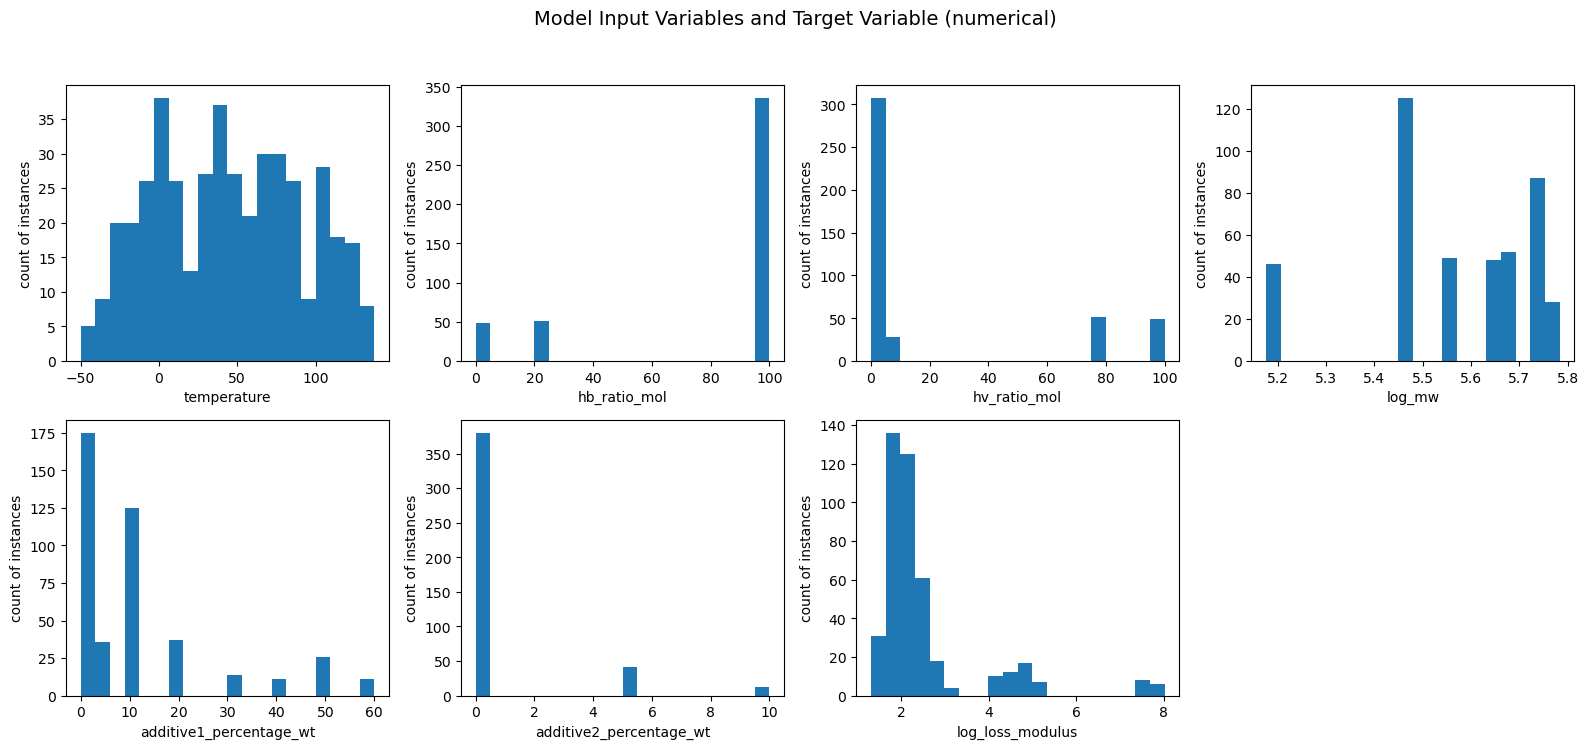

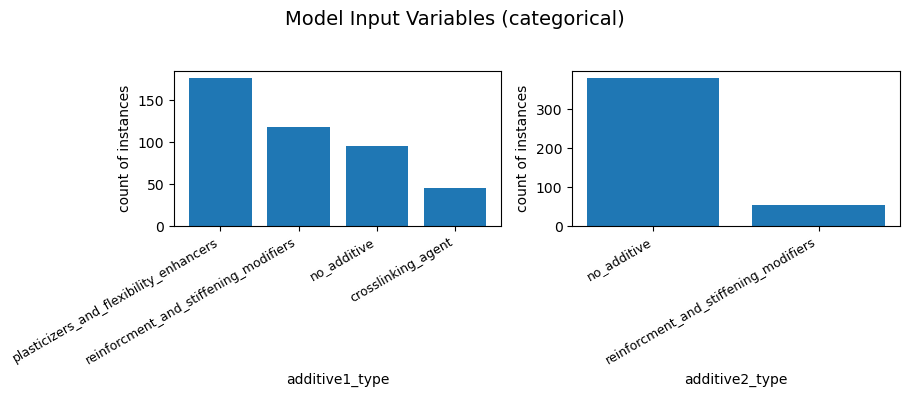

In [11]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Correlation matrix of numerical features

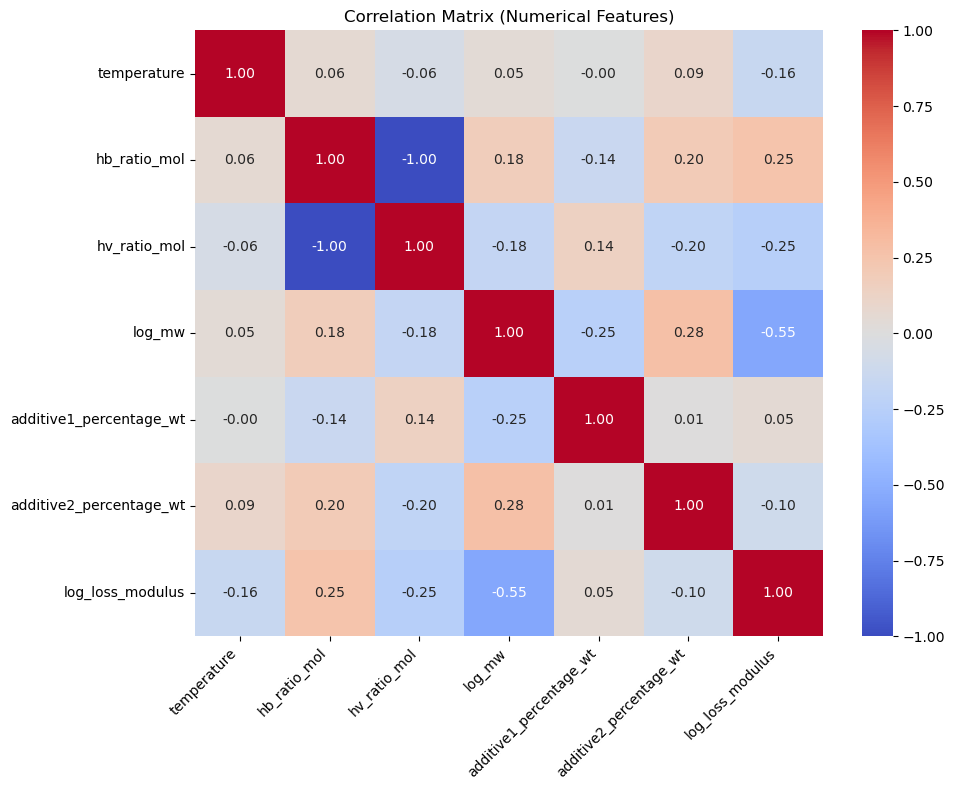

In [12]:
numerical_df = df_final[numerical_cols_lst]

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

## Train - test splitting

In [11]:
# Separate features and target
drop_cols = [target, 'hv_ratio_mol']

X = df_final.drop(columns=drop_cols)
y = df_final[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (369, 7) 
 (66, 7)t size


## FAMD for outlier detection - only on the Train set (if applied)

In [15]:
# Fit FAMD with a reasonably high number of components
famd = FAMD(n_components=20, n_iter=10, random_state=42).fit(X_train)

eigenvalues = famd.eigenvalues_
explained_inertia = eigenvalues / eigenvalues.sum()
cumulative_inertia = np.cumsum(explained_inertia)

famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,2.419,26.87%,26.87%
1,1.662,18.46%,45.34%
2,1.276,14.18%,59.51%
3,1.070,11.88%,71.40%
4,0.962,10.68%,82.08%
5,0.762,8.47%,90.55%
6,0.529,5.87%,96.42%
7,0.262,2.91%,99.33%
8,0.060,0.67%,100.00%


In [16]:
# Initial FAMD for outlier detection
n_components_initial = 8
famd2 = FAMD(n_components=n_components_initial, random_state=42)
X_train_famd = famd2.fit_transform(X_train)

X_train_famd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 369 entries, 25 to 102
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       369 non-null    float64
 1   1       369 non-null    float64
 2   2       369 non-null    float64
 3   3       369 non-null    float64
 4   4       369 non-null    float64
 5   5       369 non-null    float64
 6   6       369 non-null    float64
 7   7       369 non-null    float64
dtypes: float64(8)
memory usage: 25.9 KB


In [17]:
X_train_famd_df = X_train_famd.copy()
X_train_famd_df.columns = [f'Comp{i+1}' for i in range(X_train_famd_df.shape[1])]

X_train_famd_df.tail()

,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6,Comp7,Comp8
71,-1.156709,0.316475,1.142331,-0.135330,-0.158180,-1.167932,-1.324249,-0.578442
106,-0.740877,-1.382143,-0.183189,-1.343858,0.036092,0.621222,0.502917,0.454061
284,-1.010138,-1.196332,-1.660568,1.706484,1.147982,-1.013649,0.099494,0.310862
362,-0.938885,-1.144313,-0.828502,-1.084068,-0.668630,0.769677,-0.124349,0.067474
102,-0.972780,0.556389,1.093734,0.394271,-1.265073,-0.934976,-1.291809,-0.301965


## Outlier detection with IQR

**Test = 1:** No exclusion
**Test = 2:** +-10 IQR   **Test = 3:** +-7 IQR  

In [18]:
test = 1

# Detect outliers using IQR
def detect_iqr_outliers(df,alpha):
    outlier_indices = set()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - alpha * IQR
        upper_bound = Q3 + alpha * IQR
        outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers_col)
    return list(outlier_indices)

# Drop outliers
if test == 2:
    alpha = 3
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±2")

elif test == 3:
    alpha = 7
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±",alpha)

else:
    df_clean = df_final.copy()
    X_train_clean = X_train
    y_train_clean = y_train
    print("IQR outlier detection SKIPPED")

print(f"Original data shape: {X_train.shape}")
print(f"Cleaned data shape: {X_train_clean.shape}")

IQR outlier detection SKIPPED
Original data shape: (369, 7)
Cleaned data shape: (369, 7)


In [19]:
X_train_clean.tail()

,temperature,hb_ratio_mol,log_mw,additive1_type,additive1_percentage_wt,additive2_type,additive2_percentage_wt
71,37.933333,22.9,5.456366,reinforcment_and_stiffening_modifiers,1.0,no_additive,0.0
106,25.000000,100.0,5.653213,no_additive,0.0,no_additive,0.0
284,25.000000,100.0,5.462398,crosslinking_agent,0.5,no_additive,0.0
362,60.000000,100.0,5.467608,no_additive,0.0,no_additive,0.0
102,94.088889,22.9,5.456366,reinforcment_and_stiffening_modifiers,10.0,no_additive,0.0


## One-hot encoding

In [20]:
X_train = X_train_clean.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols_lst])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols_lst])
X_test_ohe = ohe.transform(X_test[categorical_cols_lst])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols_lst)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [21]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols_lst), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols_lst), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (369, 11)
X_test_final shape: (66, 11)


## RF and XGBoost regression

In [22]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_xgb = xgb.predict(X_train_final)
y_test_pred_xgb = xgb.predict(X_test_final)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_rf = rf.predict(X_train_final)
y_test_pred_rf = rf.predict(X_test_final)

In [23]:
y_test = y_test.copy()

def compute_metrics(y_true, y_pred):
    r,_ = pearsonr(y_true, y_pred)
    return {
        'R^2 (log)': r2_score(y_true, y_pred),
        'Pearson r (log)': r,
        'RMSE (log)': root_mean_squared_error(y_true, y_pred),
        'MAE (log)': mean_absolute_error(y_true, y_pred),
#        'RMSE': root_mean_squared_error(10 ** y_true, 10 ** y_pred),
#        'MAE': mean_absolute_error(10 ** y_true, 10 ** y_pred)
    }

metrics = []

# XGBoost
train_xgb = compute_metrics(y_train_clean, y_train_pred_xgb)
test_xgb = compute_metrics(y_test, y_test_pred_xgb)

metrics.append([
    'XGBoost', 'Train',
    train_xgb['R^2 (log)'],
    train_xgb['Pearson r (log)'],
    train_xgb['RMSE (log)'],
    train_xgb['MAE (log)']
#    train_xgb['RMSE'],
 #   train_xgb['MAE']
])

metrics.append([
    'XGBoost', 'Test',
    test_xgb['R^2 (log)'],
    test_xgb['Pearson r (log)'],
    test_xgb['RMSE (log)'],
    test_xgb['MAE (log)']
#    test_xgb['RMSE'],
 #   test_xgb['MAE']
])

# Random Forest
train_rf = compute_metrics(y_train_clean, y_train_pred_rf)
test_rf  = compute_metrics(y_test, y_test_pred_rf)

metrics.append([
    'Random Forest', 'Train',
    train_rf['R^2 (log)'],
    train_rf['Pearson r (log)'],
    train_rf['RMSE (log)'],
    train_rf['MAE (log)']
  #  train_rf['RMSE'],
   # train_rf['MAE']
])

metrics.append([
    'Random Forest', 'Test',
    test_rf['R^2 (log)'],
    test_rf['Pearson r (log)'],
    test_rf['RMSE (log)'],
    test_rf['MAE (log)']
#    test_rf['RMSE'],
 #   test_rf['MAE']
])

In [24]:
metrics_df = pd.DataFrame(
    metrics,
    columns=['Model', 'Dataset', 'R^2 (log)', 'Pearson r (log)', 'RMSE (log)', 'MAE (log)']
)

print(metrics_df)

           Model Dataset  R^2 (log)  Pearson r (log)  RMSE (log)  MAE (log)
0        XGBoost   Train   0.999555         0.999778    0.028508   0.020466
1        XGBoost    Test   0.989521         0.994904    0.074290   0.060050
2  Random Forest   Train   0.999382         0.999694    0.033585   0.024800
3  Random Forest    Test   0.984119         0.992073    0.091455   0.066308


## Grid search - RF

In [25]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search.fit(X_train_final, y_train_clean)

# Extract the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print
print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from Grid Search (CV): {best_score}")

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_rf.predict(X_train_final)
y_test_pred_grid = best_rf.predict(X_test_final)

# Metrics
r2_train_grid = r2_score(y_train_clean, y_train_pred_grid)
r2_test_grid = r2_score(y_test, y_test_pred_grid)

# Pearson r
pearson_r_train, _ = pearsonr(y_train_clean, y_train_pred_grid)
pearson_r_test, _ = pearsonr(y_test, y_test_pred_grid)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid = cross_val_score(best_rf, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid = np.mean(cv_scores_r2_grid)
std_cv_r2_grid = np.std(cv_scores_r2_grid)

# Print the R^2 scores
summary_df = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2', 'Train Pearson r', 'Test Pearson r'],
    'RF (Tuned)': [
        r2_train_grid,
        r2_test_grid,
        mean_cv_r2_grid,
        std_cv_r2_grid,
        pearson_r_train,
        pearson_r_test
    ]
})

print(summary_df)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_samples

## Plot results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Set
axes[0].scatter(10**y_train_clean, 10**y_train_pred_rf, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(10**y_train_clean), max(10**y_train_clean)],
             [min(10**y_train_clean), max(10**y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(10**y_test, 10**y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(10**y_test), max(10**y_test)],
             [min(10**y_test), max(10**y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
# plt.savefig("RF_pair.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

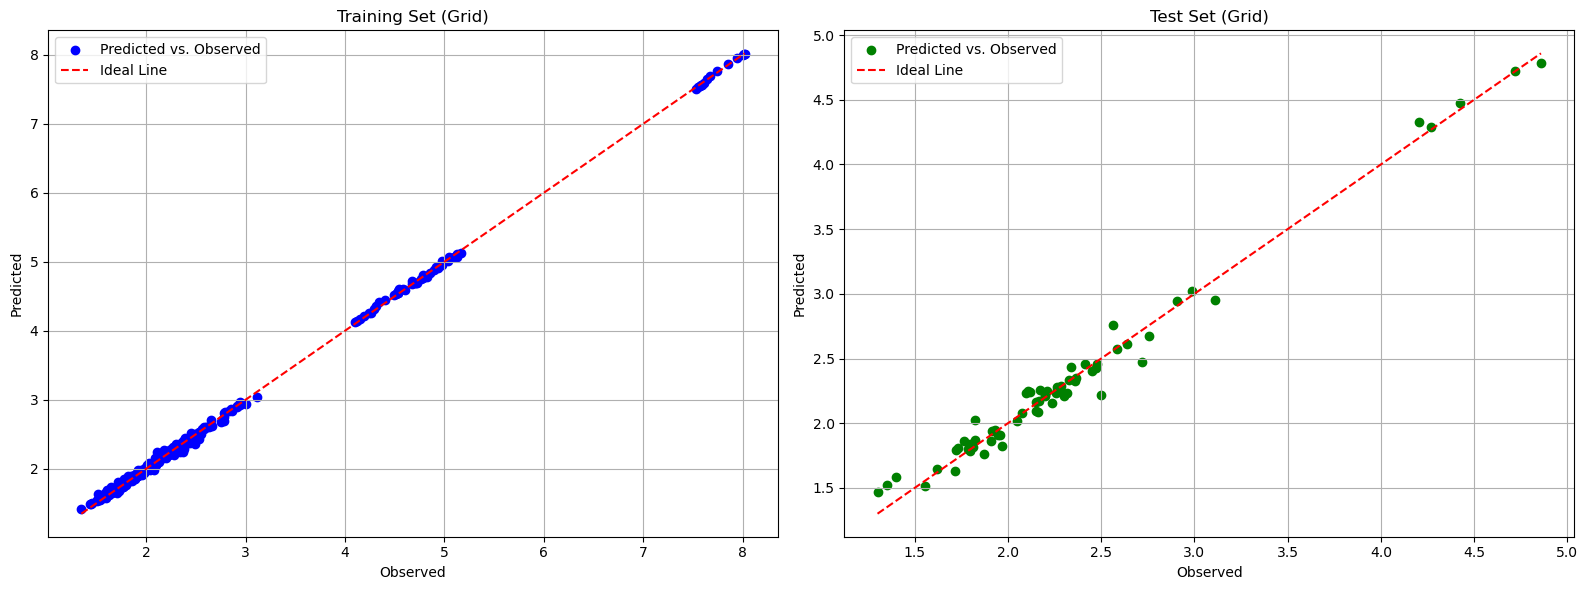

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set (Grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set (Grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("scl_dts_loss_rf_pair.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Plot RMSE w.r.t No of trees

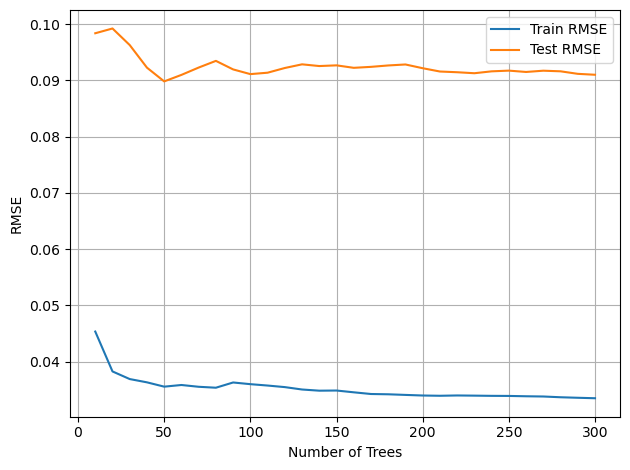

In [27]:
train_rmse = []
test_rmse = []

n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train_clean)

    y_train_pred = rf.predict(X_train_final)
    y_test_pred = rf.predict(X_test_final)

    train_rmse.append(root_mean_squared_error(y_train_clean, y_train_pred))
    test_rmse.append(root_mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(n_estimators_range, train_rmse, label="Train RMSE")
plt.plot(n_estimators_range, test_rmse, label="Test RMSE")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("scl_dts_loss_rf_rmse.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [28]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

C:\Users\User\AppData\Local\Temp\ipykernel_170352\816064441.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


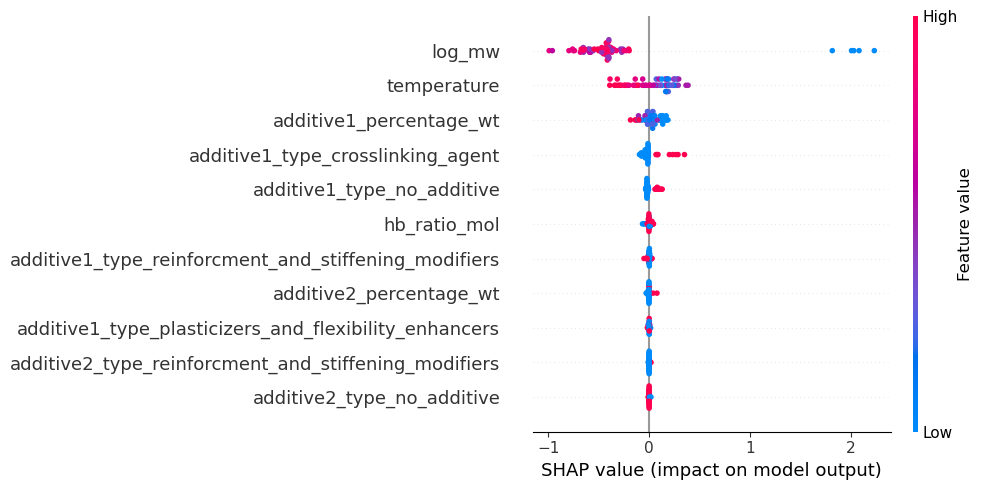

In [29]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=5,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)

plt.tight_layout()
plt.savefig("scl_dts_loss_rf_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Grid search - XGBoost

In [30]:
# Define the parameter grid
param_grid = {
     'n_estimators': [200, 400, 800],
    'learning_rate': [0.05, 0.01],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.8, 0.7]
}

# Initialize the Grid Search with Random Forest
grid_search2 = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search2.fit(X_train_final, y_train_clean)

# Extract the best parameters
best_params2 = grid_search2.best_params_
best_score2 = grid_search2.best_score_

# Print
print(f"Best parameters found: {best_params2}")
print(f"Best R^2 score from Grid Search (CV): {best_score2}")

# Use the best estimator
best_xgb = grid_search2.best_estimator_

# predictions
y_train_pred_grid2 = best_xgb.predict(X_train_final)
y_test_pred_grid2 = best_xgb.predict(X_test_final)

# Metrics
r2_train_grid2 = r2_score(y_train_clean, y_train_pred_grid2)
r2_test_grid2 = r2_score(y_test, y_test_pred_grid2)

# Pearson r
pearson_r_train2, _ = pearsonr(y_train_clean, y_train_pred_grid2)
pearson_r_test2, _ = pearsonr(y_test, y_test_pred_grid2)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid2 = cross_val_score(best_xgb, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid2 = np.mean(cv_scores_r2_grid2)
std_cv_r2_grid2 = np.std(cv_scores_r2_grid2)

# Print the R^2 scores
summary_df2 = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2', 'Train Pearson r', 'Test Pearson r'],
    'XGBoost (Tuned)': [
        r2_train_grid2,
        r2_test_grid2,
        mean_cv_r2_grid2,
        std_cv_r2_grid2,
        pearson_r_train2,
        pearson_r_test2
    ]
})

print(summary_df2)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=1.0; total time=   0.0s
[CV] END c

## Plot results

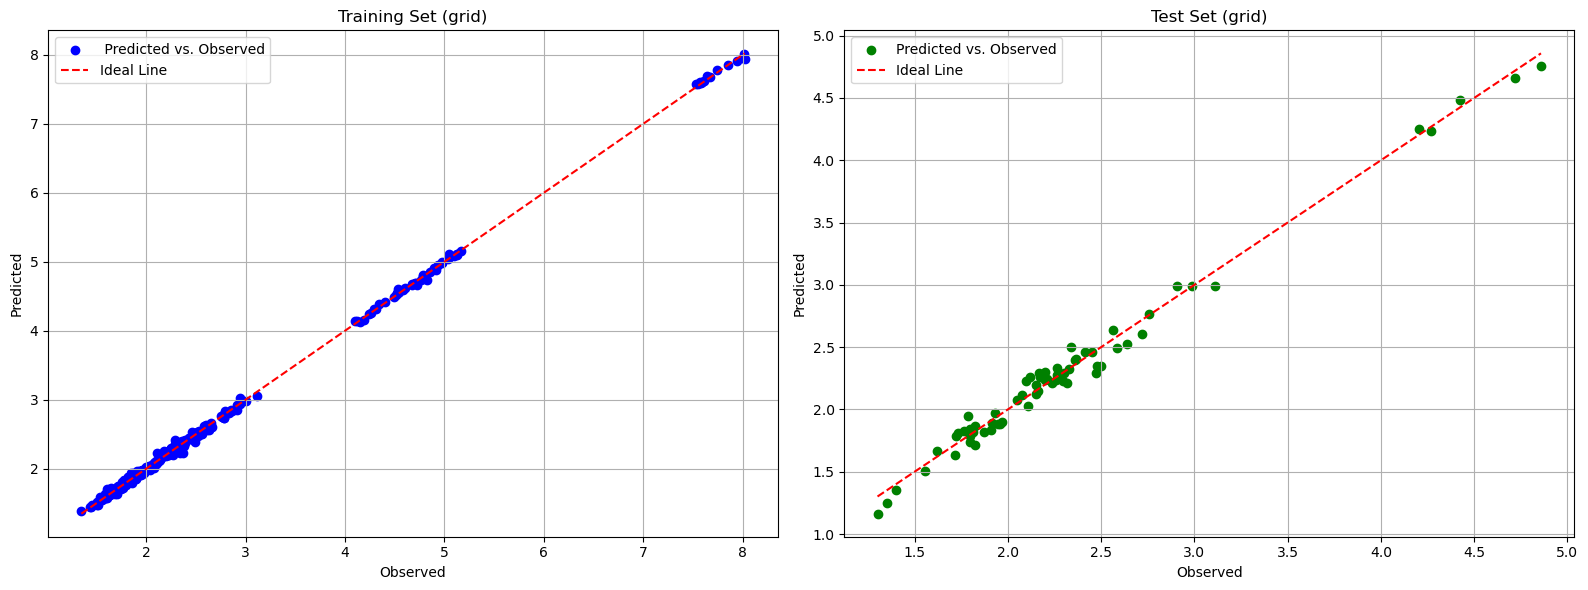

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid2, color='blue', label=' Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training Set (grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid2, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test Set (grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("scl_dts_loss_xg_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Loss plot

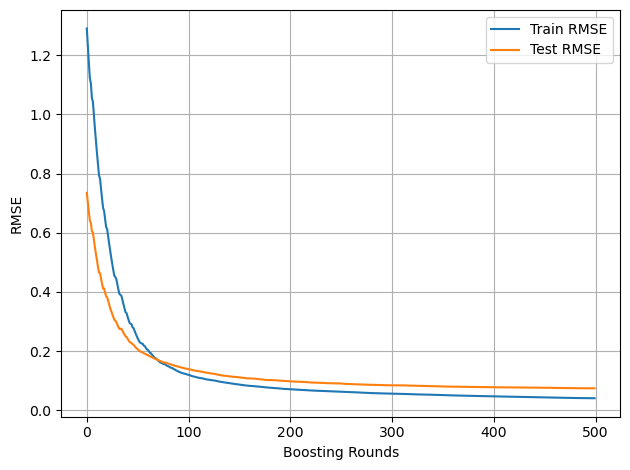

In [32]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_params2['max_depth'],
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["rmse"],
    random_state=42
)

model.fit(
    X_train_final, y_train_clean,
    eval_set=[(X_train_final, y_train_clean), (X_test_final, y_test)],
    verbose=False
)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

plt.figure()
plt.plot(range(epochs), results['validation_0']['rmse'], label="Train RMSE")
plt.plot(range(epochs), results['validation_1']['rmse'], label="Test RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("scl_dts_loss_xg_loss.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [33]:
explainer2 = shap.TreeExplainer(best_xgb)
shap_values2 = explainer2.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value2 = explainer2.expected_value

C:\Users\User\AppData\Local\Temp\ipykernel_170352\844649756.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


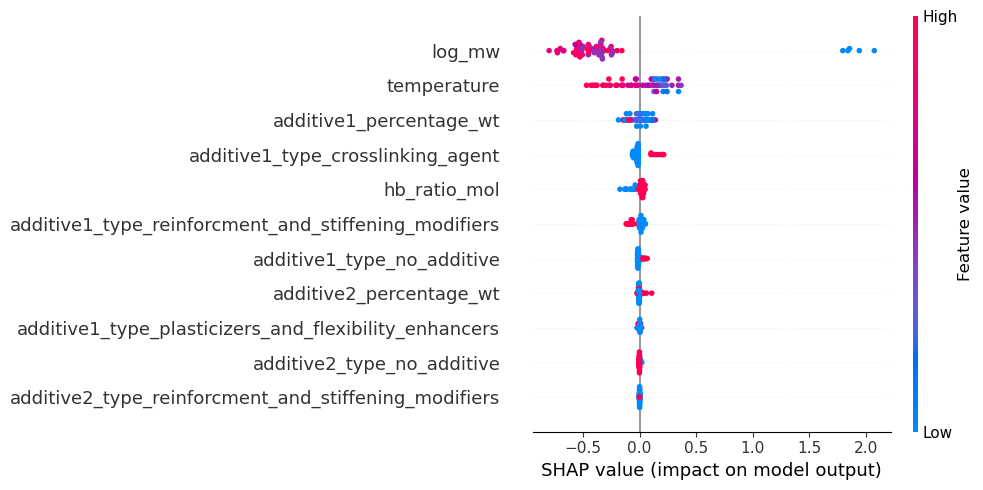

In [34]:
shap.summary_plot(
    shap_values2,
    X_test_final,
#    max_display=5,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)

plt.tight_layout()
plt.savefig("scl_dts_loss_xg_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Validation check on unseen data (excl. full instances)

In [35]:
X_val = df_val[features].copy()

X_val_ohe = ohe.transform(X_val[categorical_cols_lst])
X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
X_val_final = pd.concat([X_val.drop(columns=categorical_cols_lst), X_val_ohe_df], axis=1)

In [36]:
drop_cols = ['hv_ratio_mol']

X_val_final = X_val_final.drop(columns=drop_cols)
cols = X_val_final.columns.tolist()
first_col = cols.pop(0)

# Insert it at index 2 (third position)
cols.insert(2, first_col)
# X_val_final = X_val_final[cols]
y_val = df_val[target]

# RF
y_val_pred_rf = best_rf.predict(X_val_final)
r_rf,_ = pearsonr(y_val, y_val_pred_rf)
print(f'Pearson on unseen set (RF): {r_rf}')

# XGBoost
y_val_pred_xg = xgb.predict(X_val_final)
r_xg,_ = pearsonr(y_val, y_val_pred_xg)
print(f'Pearson on unseen set (XGB): {r_xg}')

Pearson on unseen set (RF): 0.9388496460720223
Pearson on unseen set (XGB): 0.9398401225880229


## Results table - RF

In [37]:
# RF
df_eval_rf = pd.DataFrame({
    'pos': np.arange(len(y_val)),
    'study_id': df_val['study_id'].values,
    'instance': df_val['instance'].values,
    'y_test': y_val,
    'y_pred': y_val_pred_rf
})

df_eval_rf['error'] = np.abs(df_eval_rf['y_test'] - df_eval_rf['y_pred'])

best_rows = df_eval_rf.loc[df_eval_rf.groupby('study_id')['error'].idxmin()]
best_rows_sorted = best_rows.sort_values(by='error', ascending=True)
best_rows_sorted

,pos,study_id,instance,y_test,y_pred,error
171,6,12,3b,2.213646,2.214309,0.000663
405,18,59,3,2.256365,2.242362,0.014003
218,11,21,5a,1.986817,2.013938,0.027121


## Plot results - RF

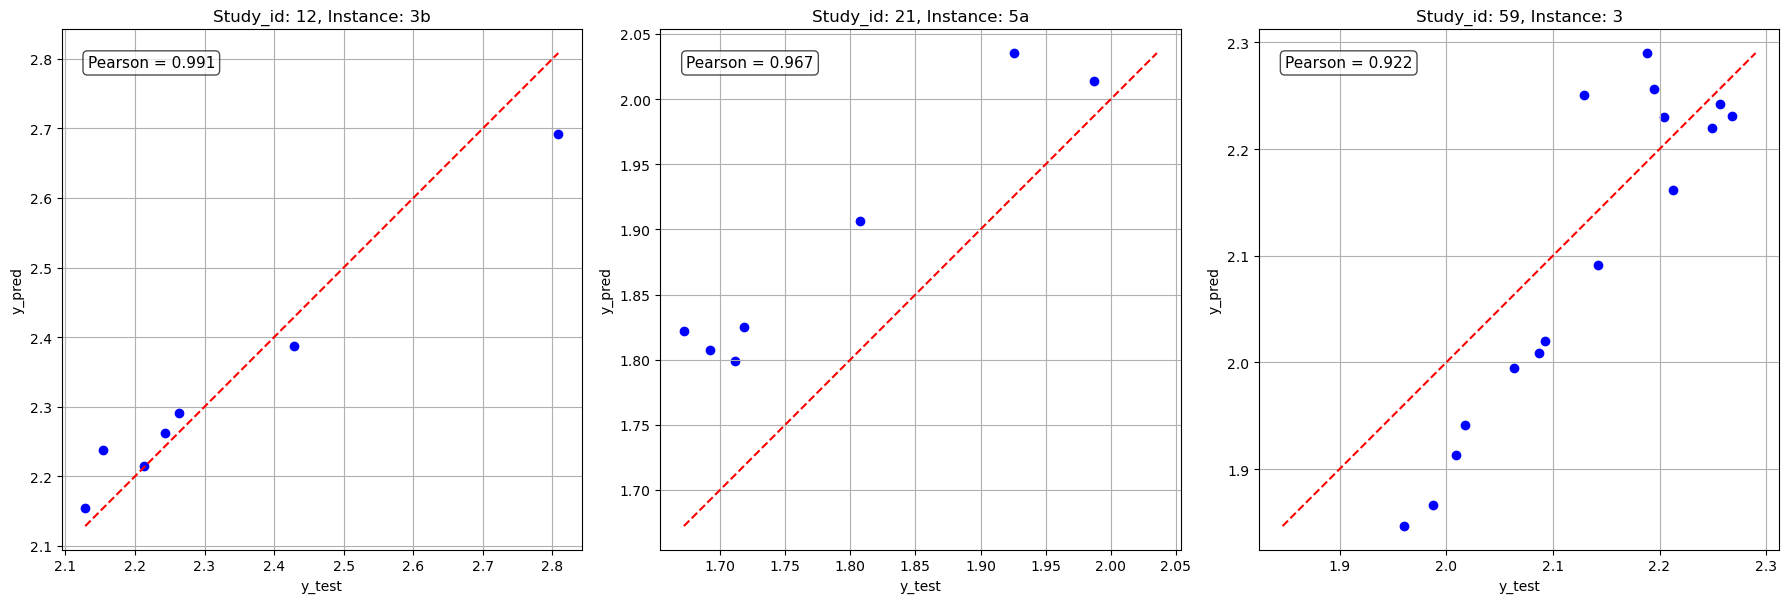

In [38]:
from scipy.stats import pearsonr

study_ids = df_eval_rf['study_id'].unique().tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear() 

    subset = df_eval_rf[df_eval_rf['study_id'] == study_id]

    r, _ = pearsonr(subset['y_test'], subset['y_pred'])

    ax.scatter(subset['y_test'], subset['y_pred'], color='blue')

    min_val = min(subset['y_test'].min(), subset['y_pred'].min())
    max_val = max(subset['y_test'].max(), subset['y_pred'].max())

    instance = subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(f'Study_id: {study_id}, Instance: {instance}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'Pearson = {r:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

In [39]:
# XGBoost
df_eval_xg = pd.DataFrame({
    'pos': np.arange(len(y_val)),
    'study_id': df_val['study_id'].values,
    'instance': df_val['instance'].values,
    'y_test': y_val,
    'y_pred': y_val_pred_xg
})

df_eval_xg['error'] = np.abs(df_eval_xg['y_test'] - df_eval_xg['y_pred'])

best_rows2 = df_eval_xg.loc[df_eval_xg.groupby('study_id')['error'].idxmin()]
best_rows_sorted2 = best_rows2.sort_values(by='error', ascending=True)
best_rows_sorted2

,pos,study_id,instance,y_test,y_pred,error
410,23,59,3,2.092821,2.086050,0.006771
165,0,12,3b,2.243072,2.261150,0.018078
214,7,21,5a,1.711723,1.770125,0.058402


## Plot results - XGBoost

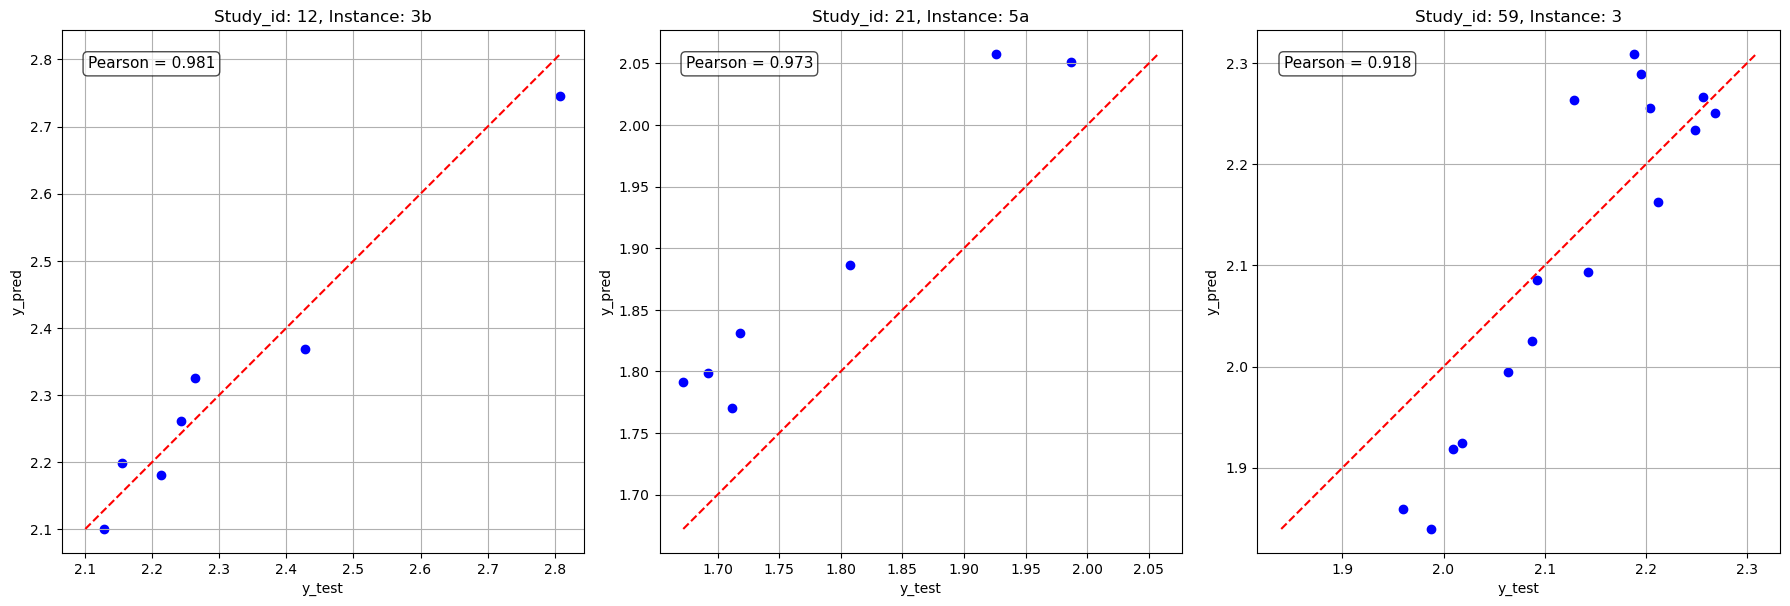

In [40]:
study_ids = df_eval_xg['study_id'].unique().tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear() 

    subset = df_eval_xg[df_eval_xg['study_id'] == study_id]

    r, _ = pearsonr(subset['y_test'], subset['y_pred'])

    ax.scatter(subset['y_test'], subset['y_pred'], color='blue')

    min_val = min(subset['y_test'].min(), subset['y_pred'].min())
    max_val = max(subset['y_test'].max(), subset['y_pred'].max())

    instance = subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(f'Study_id: {study_id}, Instance: {instance}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'Pearson = {r:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

## Williams plot

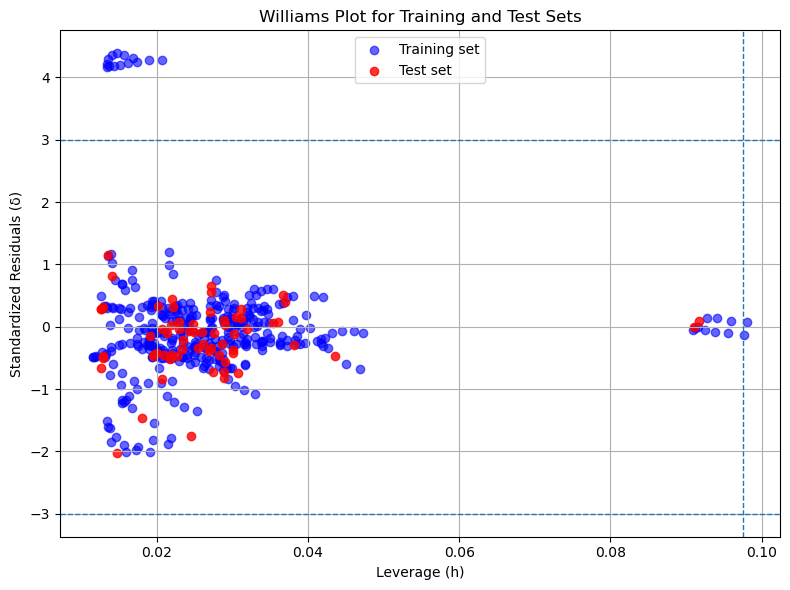

Warning leverage threshold (h*): 0.0976


In [41]:
from sklearn.linear_model import LinearRegression

# -----------------------------
# Training data
# -----------------------------
X_train = X_train_final.values if hasattr(X_train_final, "values") else X_train_final
y_train = y_train_clean.values if hasattr(y_train_clean, "values") else y_train_clean

# Test data
X_test = X_test_final.values if hasattr(X_test_final, "values") else X_test_final
y_test = y_test.values if hasattr(y_test, "values") else y_test

# -----------------------------
# Linear regression for diagnostics
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -----------------------------
# Standardized residuals (δ)
# -----------------------------
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

res_std = np.std(train_residuals)
train_delta = train_residuals / res_std
test_delta = test_residuals / res_std

# -----------------------------
# Leverage calculation
# (Hat matrix from training data)
# -----------------------------
X_train_i = np.column_stack([np.ones(X_train.shape[0]), X_train])
H = X_train_i @ np.linalg.pinv(X_train_i.T @ X_train_i) @ X_train_i.T
train_leverage = np.diag(H)

# Leverage for test set
X_test_i = np.column_stack([np.ones(X_test.shape[0]), X_test])
test_leverage = np.sum(
    X_test_i @ np.linalg.pinv(X_train_i.T @ X_train_i) * X_test_i,
    axis=1
)

# -----------------------------
# Warning leverage threshold
# -----------------------------
n = X_train_i.shape[0]
p = X_train_i.shape[1]
h_star = 3 * p / n

# -----------------------------
# Williams plot
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    train_leverage, train_delta,
    color="blue", alpha=0.6, label="Training set"
)
plt.scatter(
    test_leverage, test_delta,
    color="red", alpha=0.8, label="Test set"
)

plt.axhline(3, linestyle="--", linewidth=1)
plt.axhline(-3, linestyle="--", linewidth=1)
plt.axvline(h_star, linestyle="--", linewidth=1)

plt.xlabel("Leverage (h)")
plt.ylabel("Standardized Residuals (δ)")
plt.title("Williams Plot for Training and Test Sets")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

print(f"Warning leverage threshold (h*): {h_star:.4f}")

## Plot of best model on unseen data

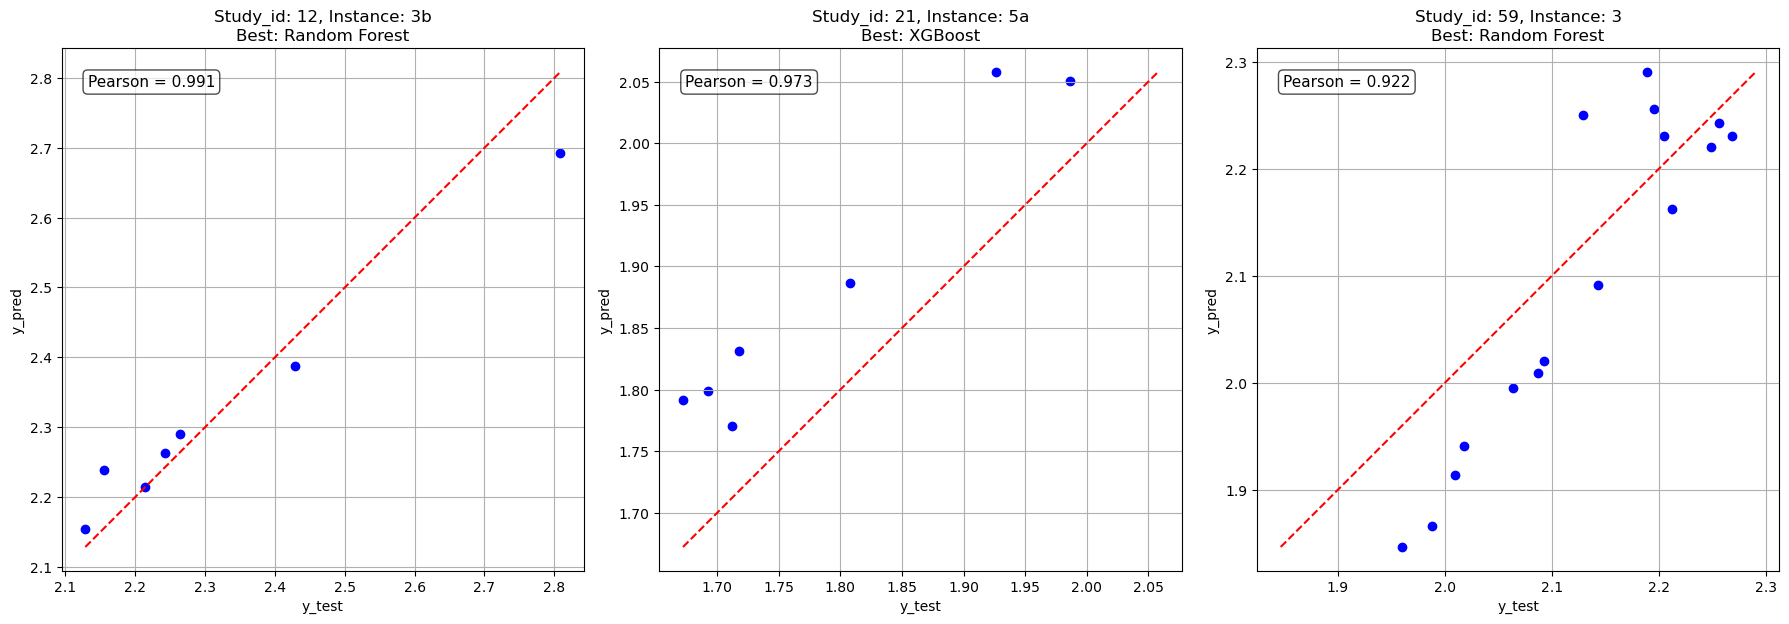

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd

# Combine study IDs from both datasets
study_ids = sorted(list(set(df_eval_xg['study_id'].unique()) | set(df_eval_rf['study_id'].unique())))

# Prepare figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear()

    # Subset for both models
    subset_xg = df_eval_xg[df_eval_xg['study_id'] == study_id]
    subset_rf = df_eval_rf[df_eval_rf['study_id'] == study_id]

    # Compute R² for both models
    r2_xg, _ = pearsonr(subset_xg['y_test'], subset_xg['y_pred']) if not subset_xg.empty else float('-inf')
    r2_rf, _ = pearsonr(subset_rf['y_test'], subset_rf['y_pred']) if not subset_rf.empty else float('-inf')

    # Choose the best model
    if r2_xg >= r2_rf:
        best_subset = subset_xg
        best_model = 'XGBoost'
        best_r2 = r2_xg
    else:
        best_subset = subset_rf
        best_model = 'Random Forest'
        best_r2 = r2_rf

    # Plot
    ax.scatter(best_subset['y_test'], best_subset['y_pred'], color='blue')

    min_val = min(best_subset['y_test'].min(), best_subset['y_pred'].min())
    max_val = max(best_subset['y_test'].max(), best_subset['y_pred'].max())

    instance = best_subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_title(f'Study_id: {study_id}, Instance: {instance}\nBest: {best_model}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'Pearson = {best_r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()  # prevent overlap
plt.savefig('scl_dts_loss_unseen.tiff', format='tiff', dpi=300)
plt.show()

## Jaqpot

In [12]:
df_loss.columns

Index(['temperature', 'study_id', 'instance', 'mw_phbv', 'additive1_type',
       'additive1_percentage_wt', 'additive2_type', 'additive2_percentage_wt',
       'hb_ratio_mol', 'hv_ratio_mol', 'loss_modulus', 'log_loss_modulus',
       'log_mw'],
      dtype='object')

In [13]:
features = [
    'temperature',
    'mw_phbv',
    'hb_ratio_mol',
    'additive1_type',
    'additive1_percentage_wt',
    'additive2_type',
    'additive2_percentage_wt'
]

target = 'loss_modulus'

measure_unit = 'MPa'

In [14]:
# Create DataFrame
df_new = df_loss[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]].copy()
df_final[target] = np.log10(df_final[target])  # log-transform
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

In [15]:
# Separate features and target
drop_cols = [target]

X = df_final.drop(columns=drop_cols)
y = df_final[target]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (369, 7) 
 Test set size (66, 7)


In [17]:
numerical_cols_lst = (
    df_final
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_cols_lst = (
    df_final
    .select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

In [18]:
numerical_cols_lst.remove(target)
features_num = numerical_cols_lst
features_cat = categorical_cols_lst

In [19]:
df_train = X_train.copy()
df_train[target] = y_train

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

df_test = X_test.copy()
df_test[target] = y_test

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [20]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat)
    ],
    remainder='drop',
)

In [21]:
model = RandomForestRegressor(random_state=42, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300)
jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=preprocessing,
  )

jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'r2': 0.9993984485840236, 'mae': 0.02431838993593525, 'rmse': 0.03314635427791317}


In [22]:
# Perform cross-validation on the training data
jaqpot_model.cross_validate(train_dataset, n_splits=10)

{'r2': 0.9942658082100909,
 'mae': 0.06614390167339608,
 'rmse': 0.08719855976147267}

In [23]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'r2': 0.9844656568493109,
 'mae': 0.06613754869388375,
 'rmse': 0.09045221177244271}

In [24]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'r2': 0.8001084272232968,
   'mae': 0.4057495816360654,
   'rmse': 0.6042221386693825},
  'Test': {'r2': -1.4873657881015454,
   'mae': 0.7849064839758626,
   'rmse': 1.1445705624667735}},
 'iteration_1': {'Train': {'r2': 0.7962125253341258,
   'mae': 0.389582522671165,
   'rmse': 0.6100818923055592},
  'Test': {'r2': -0.6786177963184807,
   'mae': 0.6760513962158936,
   'rmse': 0.9402615029832427}},
 'iteration_2': {'Train': {'r2': 0.7946597125256782,
   'mae': 0.39620692328901735,
   'rmse': 0.6124018218991615},
  'Test': {'r2': -0.4669368267859424,
   'mae': 0.5823852490229152,
   'rmse': 0.8789788989742422}},
 'iteration_3': {'Train': {'r2': 0.8055949029859639,
   'mae': 0.4056016646717176,
   'rmse': 0.5958723243982822},
  'Test': {'r2': -2.070535305465197,
   'mae': 0.8776397284971722,
   'rmse': 1.27168571057928}},
 'iteration_4': {'Train': {'r2': 0.8025406371553728,
   'mae': 0.4061299963077299,
   'rmse': 0.60053490751143},
  'Test': {'r2': -1.280829

In [25]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)
print(doa_predictions)

{'LEVERAGE': [{'h': 0.036647272618185046, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.0282782976693034, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.020374332583309857, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.03019178478210152, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.024612907134024767, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.025431047171724456, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.030024203857968987, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.023448743366210053, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.021426045639986385, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.03131358399408682, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.012838061670767608, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.02773496875384386, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.01887174755064499, 'hStar': 0.08943089430894309, 'inDoa': True}, {'h': 0.030577656808431986, 'h

In [26]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 66, 'n_in': 64, 'n_out': 2},
 'BOUNDING_BOX': {'n_total': 66, 'n_in': 66, 'n_out': 0}}

In [27]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Loss modulus regression model for scl-PHAs A.N.I.P.H. (v2)",
    description="Prediction of log-transformed loss modulus for scl-PHAs using Dynamic Temperature Sweep (DTS) data. To convert to actual loss modulus: modulus = 10^(predicted value).",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-07-08 21:09:45,292 - INFO - Large model detected, using /v1/large-models flow
  2026-07-08 21:09:47,957 - INFO - Uploading your model directly to s3, due to its large size...
Uploading:  99%|█████████▉| 5.24M/5.29M [00:04<00:00, 1.25MB/s]

✅ File uploaded successfully.


Uploading: 100%|██████████| 5.29M/5.29M [00:04<00:00, 1.07MB/s]
  2026-07-08 21:09:53,123 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2390


In [28]:
df_train[features_num].agg(['min','max'])

,temperature,mw_phbv,hb_ratio_mol,additive1_percentage_wt,additive2_percentage_wt
min,-50.0,150000.0,0.0,0.0,0.0
max,137.5,607000.0,100.0,60.0,10.0
